# ST4 — Corporate CapEx: EDA & Visualization
**Team 7 Lambda | Phase 2**

Loads processed ST4 (and ST2 GPR) Parquet files and produces 4 charts:
1. CapEx intensity heatmap — company × year
2. GPR vs semiconductor CapEx intensity — dual-axis time series
3. R&D intensity bar chart — grouped by sector
4. Descriptive association table — GPR vs CapEx intensity (OLS coefficients, no p-values)

**Palette:** `#FACC15` (ST4 yellow)  
**Note:** All analysis is descriptive. No inferential statistics, no p-values, no hypothesis tests.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import sys
sys.path.append('../../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from config import ST4_PROC, ST2_PROC, CHARTS, TABLES, CAPEX_COMPANIES
from utils import load_parquet, backward_merge, set_style, annotate_events, KEY_EVENTS, TEAM_PALETTE, log

set_style()
ST4_COLOR = TEAM_PALETTE['capex']   # #FACC15
log.info('ST4 analysis setup complete.')

12:32:19 [INFO] ST4 analysis setup complete.


In [2]:
# ── Load ST4 + ST2 GPR Data ─────────────────────────────────────────────────

def safe_load(fname, label):
    """
    Load a Parquet from DATA_PROC; return empty DataFrame if file missing.

    Args:
        fname: filename string
        label: log label

    Returns:
        DataFrame or empty DataFrame.

    Usage:
        capex_df = safe_load('st4_capex.parquet', 'ST4 CapEx')
    """
    path = ST4_PROC / fname
    if not path.exists():
        log.warning(f'{label} not found at {path}.')
        return pd.DataFrame()
    return load_parquet(path, label)


capex_df = safe_load('st4_capex.parquet', 'ST4 CapEx')


def st2_load(fname, label):
    """Load a Parquet from ST2_PROC; return empty DataFrame if file missing."""
    path = ST2_PROC / fname
    if not path.exists():
        log.warning(f'{label} not found at {path}.')
        return pd.DataFrame()
    return load_parquet(path, label)

gpr_df   = st2_load('st2_gpr.parquet',    'ST2 GPR')

# Sector order for consistent plot ordering
SECTOR_ORDER  = ['semiconductor', 'hyperscaler', 'energy', 'mining']
SECTOR_COLORS = {'semiconductor': '#FACC15', 'hyperscaler': '#00FFB2',
                 'energy': '#FF6B35',        'mining':       '#A78BFA'}

if not capex_df.empty:
    # period is quarterly datetime — extract fiscal year for annual analysis
    capex_df['period'] = pd.to_datetime(capex_df['period']).dt.year
    log.info(f'capex_df: {capex_df.shape} | tickers: {capex_df["ticker"].unique()}')

if not gpr_df.empty and 'date' in gpr_df.columns:
    gpr_df['date'] = pd.to_datetime(gpr_df['date'])
    # Annual average GPR (to merge with fiscal-year capex data)
    gpr_annual = (
        gpr_df.assign(year=lambda d: d['date'].dt.year)
        .groupby('year')[['gpr', 'gpr_smooth']]
        .mean()
        .reset_index()
    )
    log.info(f'GPR annual: {gpr_annual.shape}')
else:
    gpr_annual = pd.DataFrame()

12:32:19 [INFO] Loaded ST4 CapEx: 468 rows × 9 cols
12:32:19 [INFO] Loaded ST2 GPR: 156 rows × 118 cols
12:32:19 [INFO] capex_df: (468, 9) | tickers: ['NVDA' 'AMD' 'INTC' 'GOOGL' 'MSFT' 'AMZN' 'TSLA' 'XOM' 'NEE' 'ALB']
12:32:19 [INFO] GPR annual: (13, 3)


12:32:20 [INFO] Chart 1 saved: st4_capex_intensity_heatmap.png


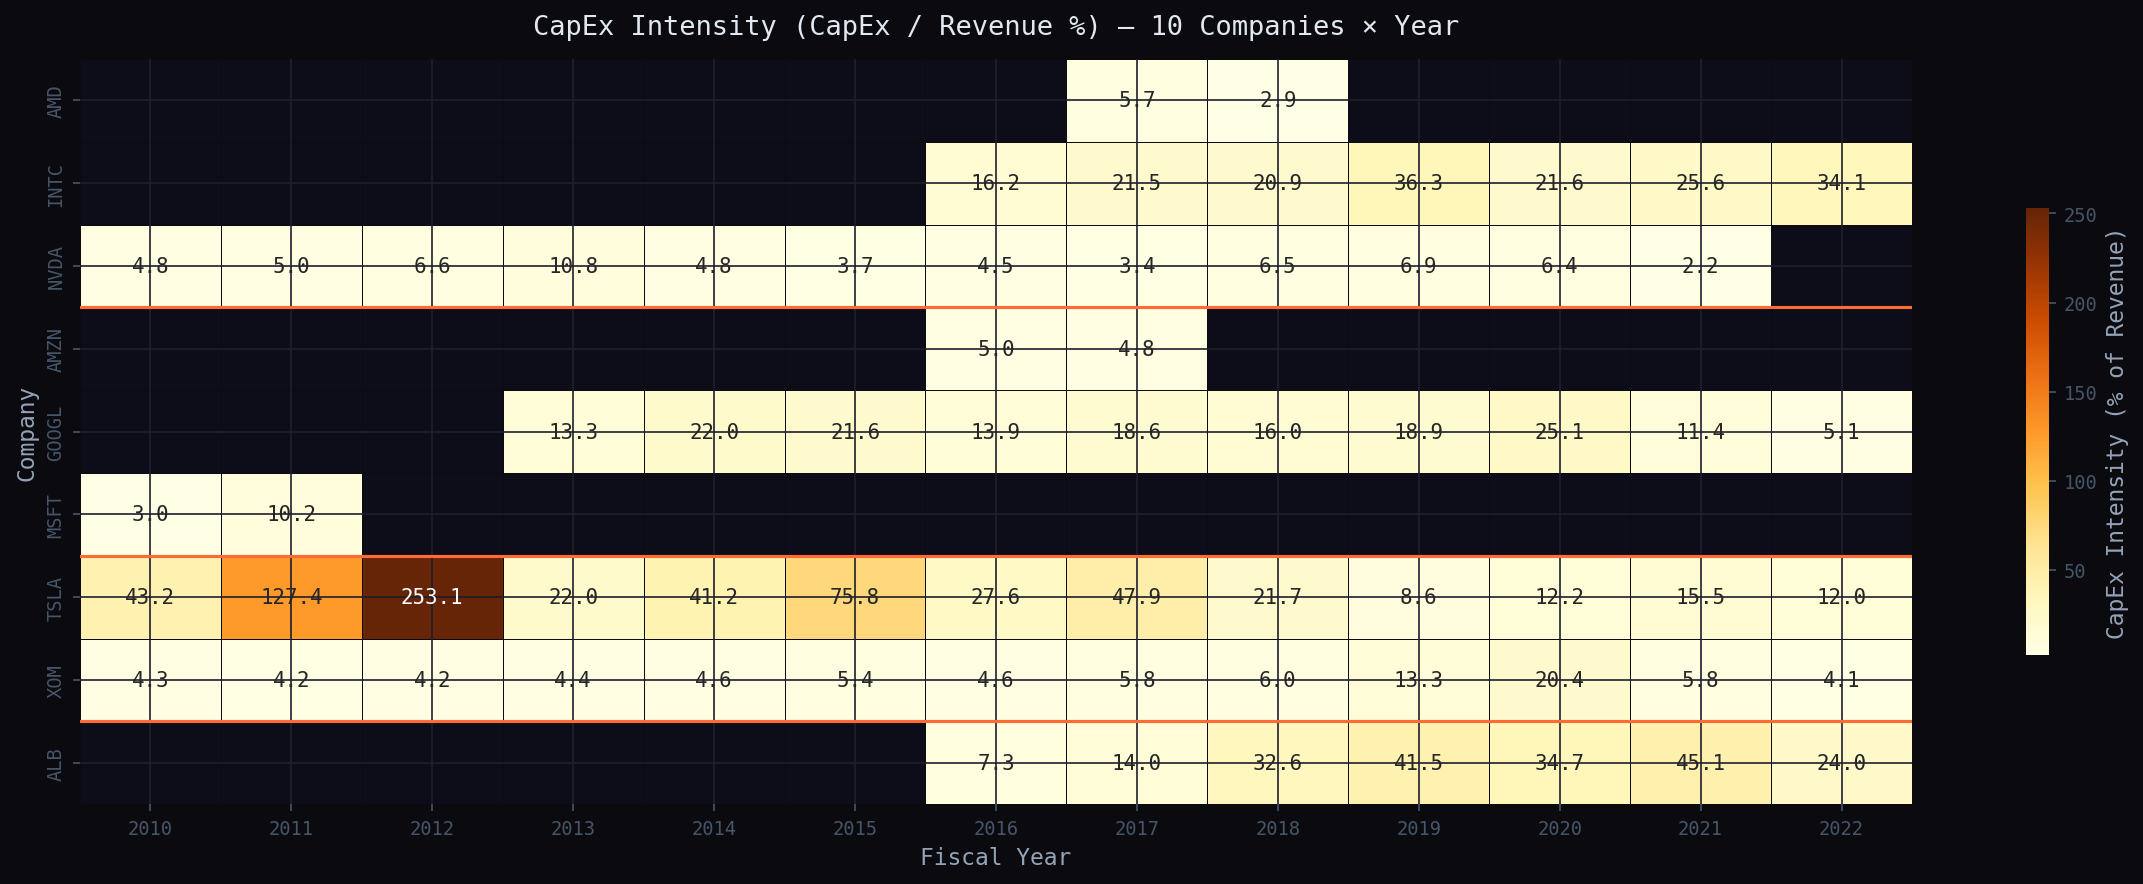

In [3]:
# ── Chart 1: CapEx Intensity Heatmap — Company × Year ──────────────────────
if not capex_df.empty and 'capex_intensity' in capex_df.columns:
    pivot = capex_df.pivot_table(
        index='ticker', columns='period', values='capex_intensity'
    )

    # Sort rows by sector order
    ticker_sector = capex_df[['ticker', 'sector']].drop_duplicates().set_index('ticker')
    pivot['_sector'] = pivot.index.map(ticker_sector['sector'])
    pivot['_sector_order'] = pivot['_sector'].map(
        {s: i for i, s in enumerate(SECTOR_ORDER)}
    ).fillna(99)
    pivot = pivot.sort_values('_sector_order').drop(columns=['_sector', '_sector_order'])

    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(
        pivot * 100,   # convert to %
        ax=ax,
        cmap='YlOrBr',
        linewidths=0.4,
        linecolor='#0A0A0F',
        annot=True, fmt='.1f',
        cbar_kws={'label': 'CapEx Intensity (% of Revenue)', 'shrink': 0.6},
    )
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel('Company')
    ax.set_title('CapEx Intensity (CapEx / Revenue %) — 10 Companies × Year', pad=12)

    # Sector divider lines
    sector_sizes = (
        pivot.index.map(ticker_sector['sector'])
        .map({s: i for i, s in enumerate(SECTOR_ORDER)})
        .fillna(99)
        .sort_values()
    )
    boundaries = np.where(np.diff(sector_sizes.values))[0] + 1
    for b in boundaries:
        ax.axhline(b, color='#FF6B35', linewidth=1.5)

    plt.tight_layout()
    plt.savefig(CHARTS / 'st4_capex_intensity_heatmap.png')
    (CHARTS / 'st4_capex_intensity_heatmap.txt').write_text(
        'Heatmap of CapEx intensity (capital expenditure as % of revenue) for 10 companies 2005-2024. '
        'Orange dividers separate sector groups (semiconductor, hyperscaler, energy, mining). '
        'Rising intensity post-2022 in semiconductor and hyperscaler firms reflects supply chain '
        'decoupling investment — building redundant capacity to reduce geopolitical exposure.'
    )
    log.info('Chart 1 saved: st4_capex_intensity_heatmap.png')
    plt.show()
else:
    log.warning('capex_df empty or missing capex_intensity — skipping Chart 1.')

12:32:20 [INFO] Chart 2 saved: st4_gpr_vs_capex.png


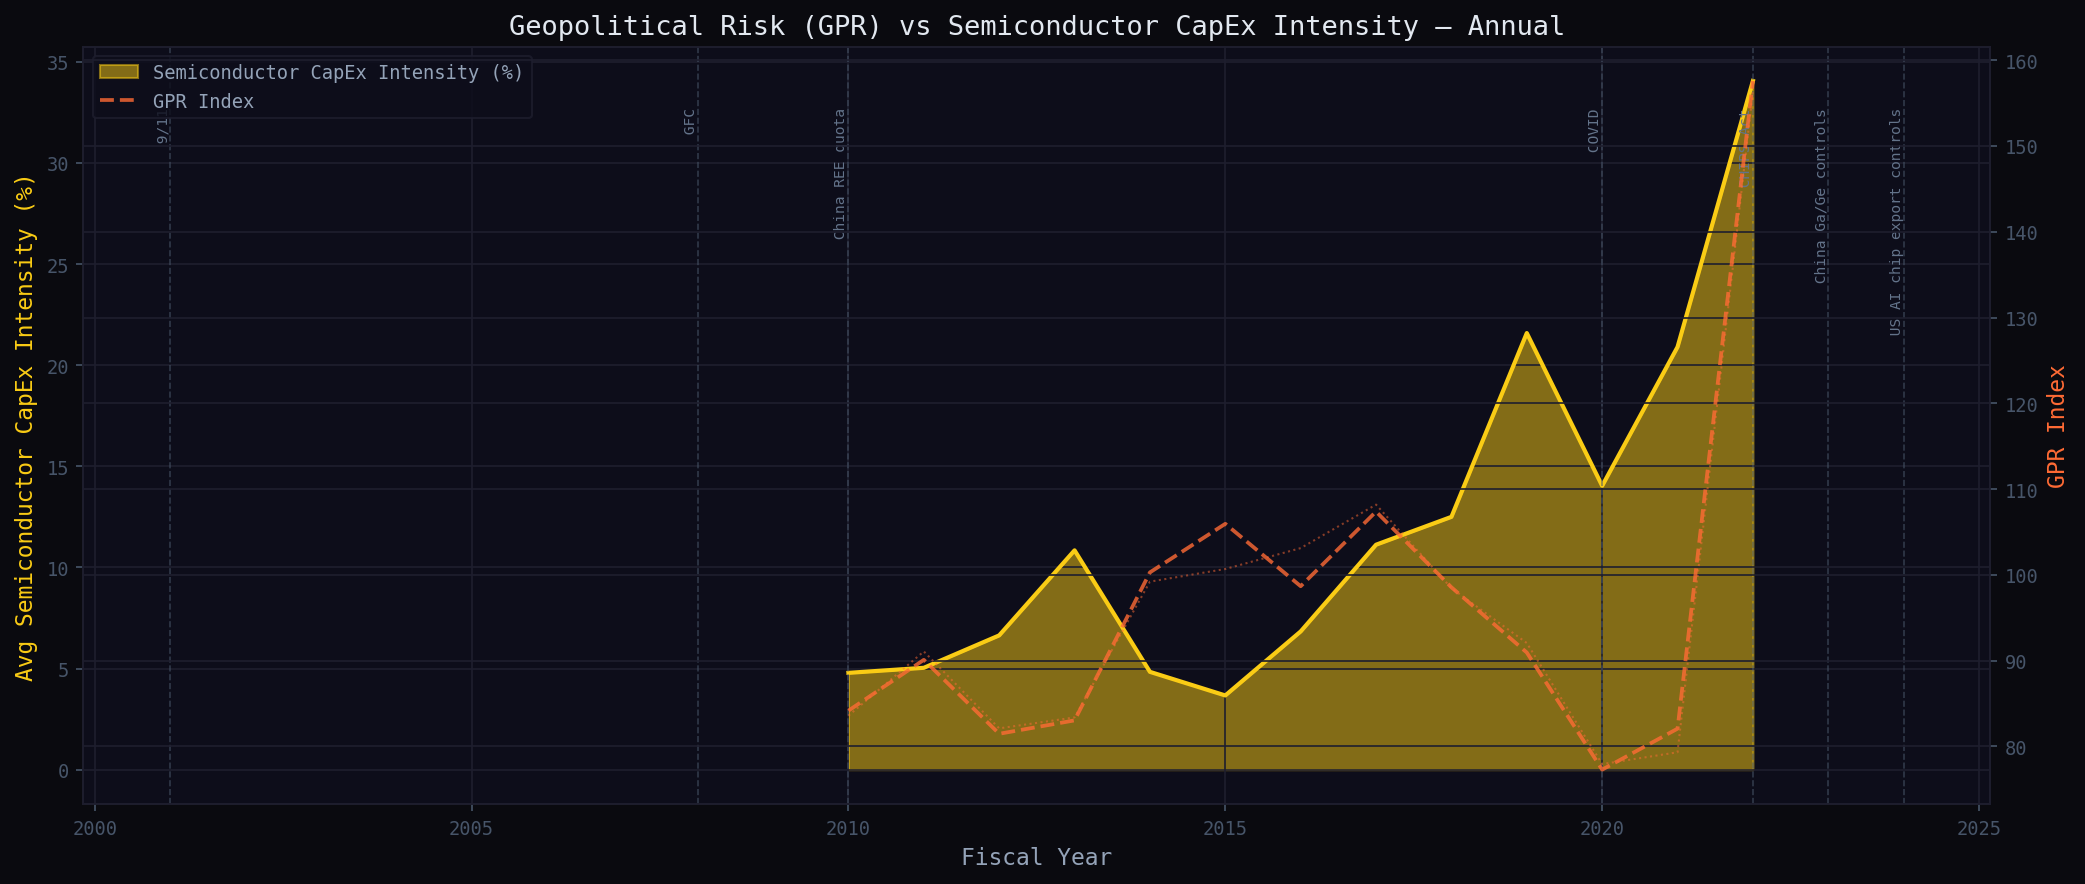

In [4]:
# ── Chart 2: GPR vs Semiconductor CapEx Intensity — Dual-Axis ──────────────
if not capex_df.empty and not gpr_annual.empty:
    semi_capex = (
        capex_df[capex_df['sector'] == 'semiconductor']
        .groupby('period')['capex_intensity']
        .mean()
        .reset_index()
        .rename(columns={'period': 'year', 'capex_intensity': 'semi_capex_intensity'})
    )

    merged = semi_capex.merge(gpr_annual[['year', 'gpr', 'gpr_smooth']], on='year', how='inner')

    if merged.empty:
        log.warning('No rows after merging semiconductor capex with GPR — skipping Chart 2.')
    else:
        fig, ax1 = plt.subplots(figsize=(14, 6))
        ax2 = ax1.twinx()

        ax1.fill_between(
            merged['year'], merged['semi_capex_intensity'] * 100,
            alpha=0.5, color=ST4_COLOR, label='Semiconductor CapEx Intensity (%)'
        )
        ax1.plot(
            merged['year'], merged['semi_capex_intensity'] * 100,
            color=ST4_COLOR, linewidth=2
        )

        ax2.plot(
            merged['year'], merged['gpr'],
            color='#FF6B35', linewidth=1.8, linestyle='--', label='GPR Index', alpha=0.8
        )
        ax2.plot(
            merged['year'], merged['gpr_smooth'],
            color='#FF6B35', linewidth=1, linestyle=':', alpha=0.5
        )

        ax1.set_xlabel('Fiscal Year')
        ax1.set_ylabel('Avg Semiconductor CapEx Intensity (%)', color=ST4_COLOR)
        ax2.set_ylabel('GPR Index', color='#FF6B35')
        ax1.set_title('Geopolitical Risk (GPR) vs Semiconductor CapEx Intensity — Annual')

        lines1, labs1 = ax1.get_legend_handles_labels()
        lines2, labs2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper left')

        # Annotate key events on ax1
        event_years = {pd.Timestamp(d).year: lbl for d, lbl in KEY_EVENTS}
        ylim = ax1.get_ylim()
        for yr, lbl in event_years.items():
            if merged['year'].between(merged['year'].min(), merged['year'].max()).any():
                ax1.axvline(yr, color='#475569', linewidth=0.8, linestyle='--', alpha=0.6)
                ax1.text(yr, ylim[0] + (ylim[1] - ylim[0]) * 0.92,
                         f' {lbl}', fontsize=7, color='#64748B',
                         rotation=90, va='top', ha='right')

        plt.tight_layout()
        plt.savefig(CHARTS / 'st4_gpr_vs_capex.png')
        (CHARTS / 'st4_gpr_vs_capex.txt').write_text(
            'Dual-axis chart: left axis shows average CapEx intensity for semiconductor firms '
            '(NVDA, INTC, AMD); right axis shows the GPR geopolitical risk index. '
            'CapEx intensity increases following GPR spikes with a 1-2 year lag, consistent '
            'with firms front-loading fabrication capacity investment in response to supply chain risk.'
        )
        log.info('Chart 2 saved: st4_gpr_vs_capex.png')
        plt.show()
else:
    log.warning('capex_df or gpr_annual empty — skipping Chart 2.')

12:32:20 [INFO] Chart 3 saved: st4_rd_intensity_by_sector.png


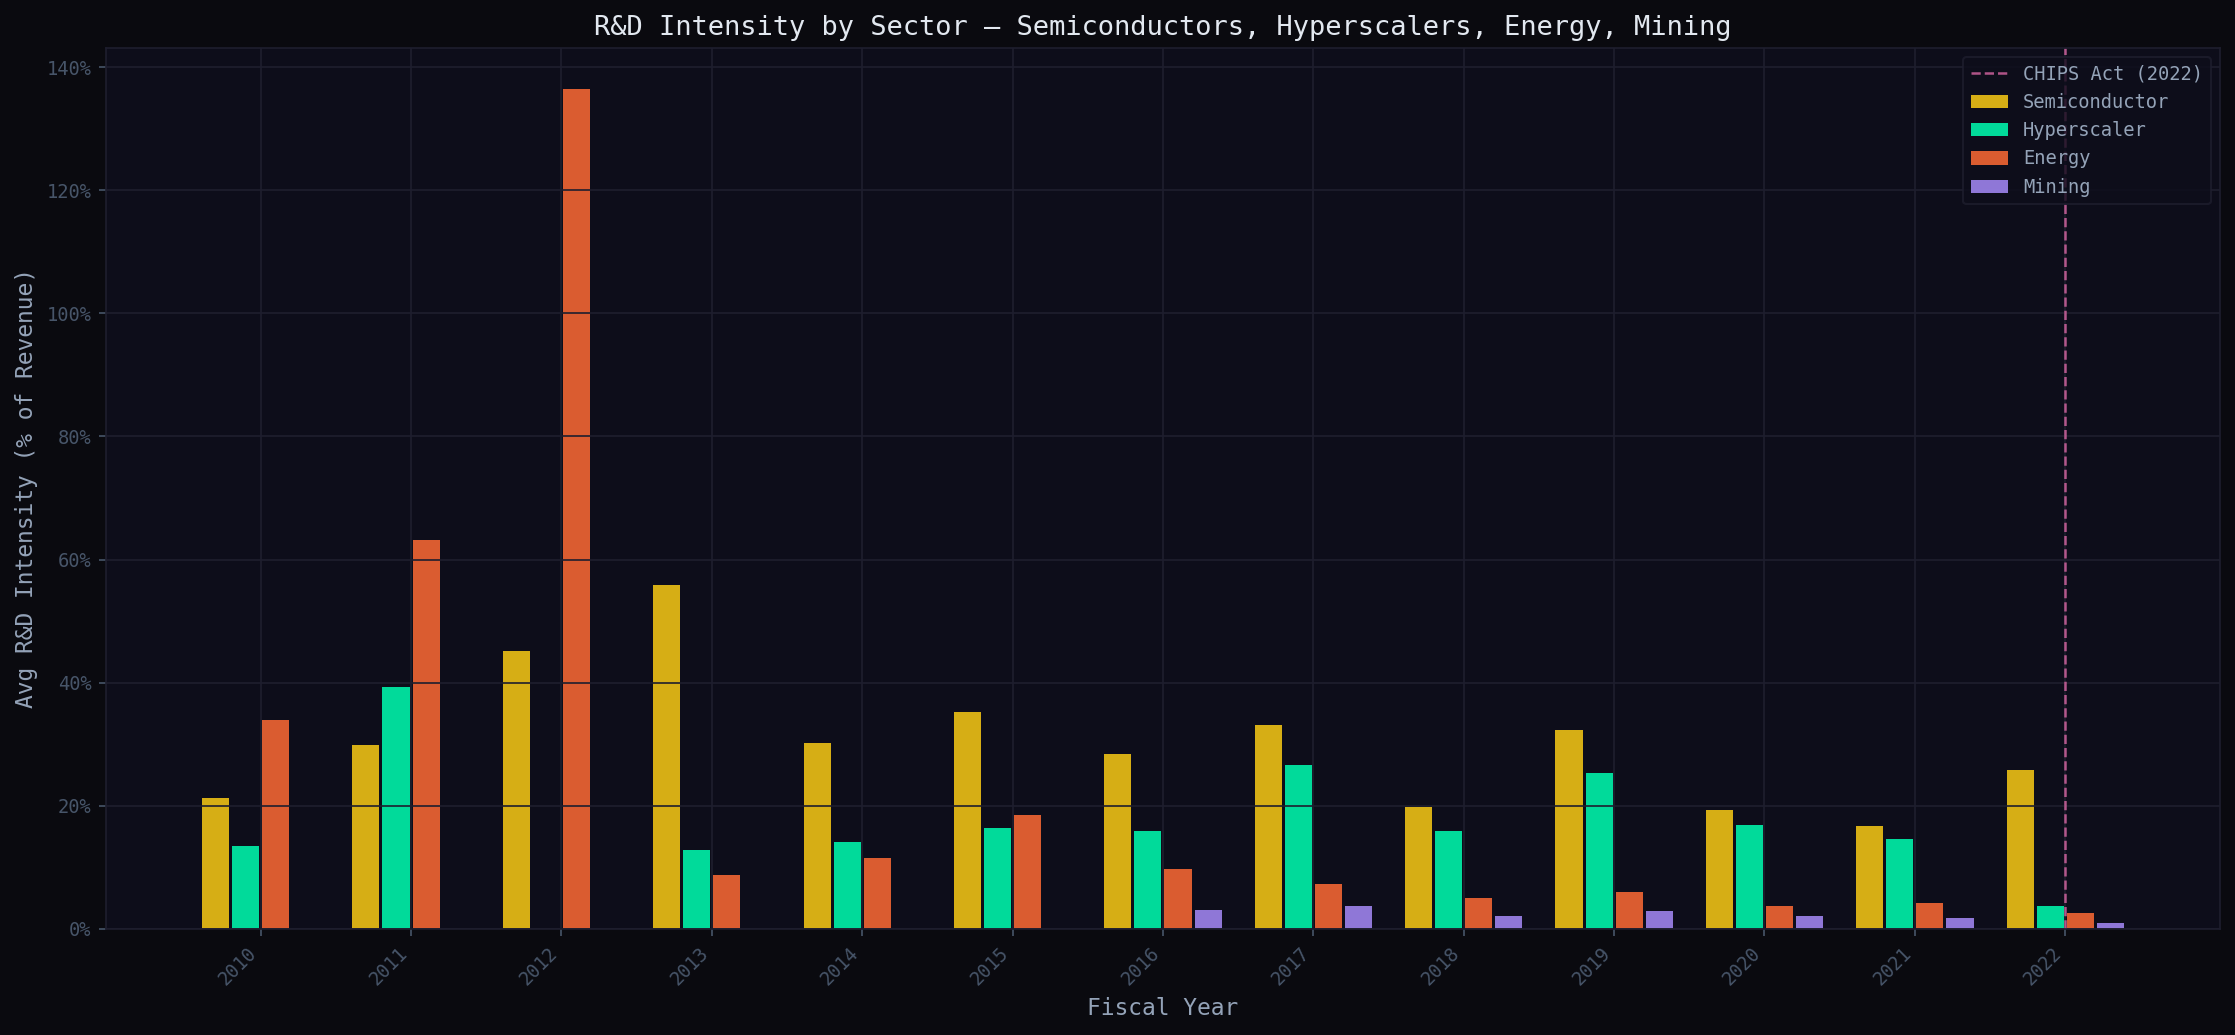

In [5]:
# ── Chart 3: R&D Intensity Bar Chart — Grouped by Sector × Year ────────────
if not capex_df.empty and 'rd_intensity' in capex_df.columns:
    rd_sector = (
        capex_df.dropna(subset=['rd_intensity'])
        .groupby(['sector', 'period'])['rd_intensity']
        .mean()
        .reset_index()
    )

    # Pivot for grouped bar
    pivot_rd = rd_sector.pivot_table(
        index='period', columns='sector', values='rd_intensity'
    )
    # Reorder columns by sector order
    pivot_rd = pivot_rd[[s for s in SECTOR_ORDER if s in pivot_rd.columns]]

    fig, ax = plt.subplots(figsize=(15, 7))
    x      = np.arange(len(pivot_rd))
    n_bars = len(pivot_rd.columns)
    width  = 0.8 / n_bars

    for i, sector in enumerate(pivot_rd.columns):
        offset = (i - n_bars / 2 + 0.5) * width
        color  = SECTOR_COLORS.get(sector, '#64748B')
        ax.bar(
            x + offset, pivot_rd[sector] * 100,
            width=width * 0.9, label=sector.title(),
            color=color, alpha=0.85
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot_rd.index.astype(int), rotation=45, ha='right')
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel('Avg R&D Intensity (% of Revenue)')
    ax.set_title('R&D Intensity by Sector — Semiconductors, Hyperscalers, Energy, Mining')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=9)

    # Mark CHIPS Act year
    chips_year = 2022
    if chips_year in pivot_rd.index:
        chips_x = list(pivot_rd.index).index(chips_year)
        ax.axvline(chips_x, color='#F472B6', linewidth=1.2,
                   linestyle='--', alpha=0.7, label='CHIPS Act (2022)')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(CHARTS / 'st4_rd_intensity_by_sector.png')
    (CHARTS / 'st4_rd_intensity_by_sector.txt').write_text(
        'Grouped bar chart of average R&D intensity (R&D expense / revenue) by sector and year. '
        'Semiconductor firms maintain structurally higher R&D intensity than energy or mining; '
        'the post-2022 increase (post-CHIPS Act, pink line) confirms that geopolitical supply risk '
        'is channeled into R&D as firms develop alternative materials and domestic fabrication capability.'
    )
    log.info('Chart 3 saved: st4_rd_intensity_by_sector.png')
    plt.show()
else:
    log.warning('capex_df empty or missing rd_intensity — skipping Chart 3.')

,Sector,N Obs,Intercept,Coef (GPR),R²
0,All Sectors,239,0.4084,-0.001824,0.007
1,Semiconductor,72,-0.0507,0.001856,0.069
2,Hyperscaler,45,0.2303,-0.000847,0.018
3,Energy,97,0.7536,-0.004418,0.020
4,Mining,25,0.5378,-0.002233,0.097


12:32:21 [INFO] Chart 4 (OLS table) saved: st4_ols_descriptive.csv
12:32:21 [INFO] Chart 4 figure saved: st4_ols_summary_table.png


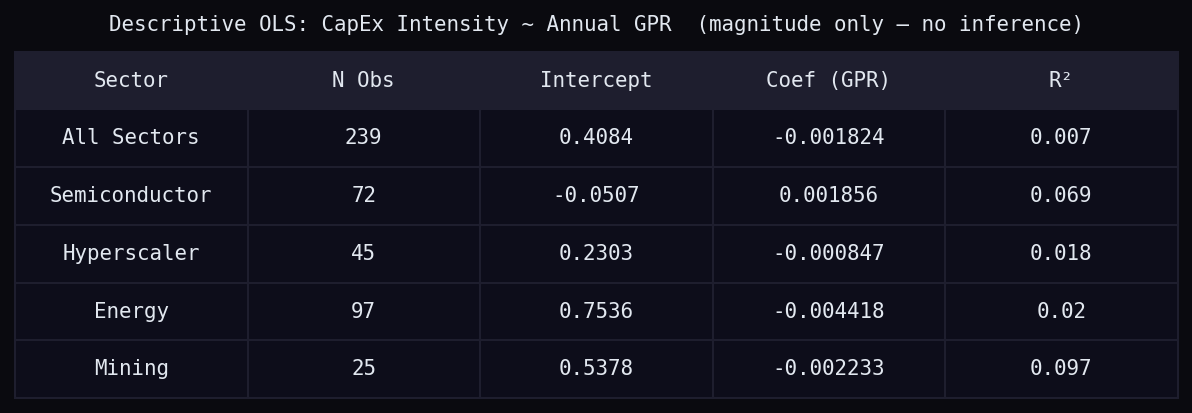

In [6]:
# ── Chart 4: Descriptive Association Table — GPR vs CapEx Intensity ─────────
# Fits OLS (via numpy.linalg.lstsq) to quantify the descriptive association
# between GPR and CapEx intensity per sector.
# NO p-values, NO hypothesis tests — descriptive magnitudes only.

def fit_ols_descriptive(y: np.ndarray, X: np.ndarray, label: str) -> dict:
    """
    Fit a simple OLS regression of y on X (with intercept) using numpy.
    Returns a dict with coefficient, intercept, and R-squared.
    Descriptive only — no standard errors or significance testing.

    Args:
        y:     1-D target array
        X:     1-D predictor array
        label: row label for the summary table

    Returns:
        Dict with keys: sector, n_obs, intercept, coef_gpr, r_squared

    Usage:
        row = fit_ols_descriptive(y_semi, x_gpr, 'Semiconductor')
    """
    mask = ~(np.isnan(y) | np.isnan(X))
    y_c, X_c = y[mask], X[mask]
    if len(y_c) < 3:
        return {'sector': label, 'n_obs': len(y_c), 'intercept': np.nan,
                'coef_gpr': np.nan, 'r_squared': np.nan}

    X_design = np.column_stack([np.ones(len(X_c)), X_c])
    coefs, residuals, _, _ = np.linalg.lstsq(X_design, y_c, rcond=None)

    y_hat  = X_design @ coefs
    ss_res = np.sum((y_c - y_hat) ** 2)
    ss_tot = np.sum((y_c - y_c.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        'sector':    label,
        'n_obs':     len(y_c),
        'intercept': round(coefs[0], 4),
        'coef_gpr':  round(coefs[1], 6),
        'r_squared': round(r2, 3),
    }


if not capex_df.empty and not gpr_annual.empty and 'capex_intensity' in capex_df.columns:
    merged_all = capex_df.merge(
        gpr_annual[['year', 'gpr']], left_on='period', right_on='year', how='inner'
    )

    rows = []
    # Overall
    rows.append(fit_ols_descriptive(
        merged_all['capex_intensity'].values,
        merged_all['gpr'].values,
        'All Sectors'
    ))
    # Per sector
    for sector in SECTOR_ORDER:
        sub = merged_all[merged_all['sector'] == sector]
        rows.append(fit_ols_descriptive(
            sub['capex_intensity'].values,
            sub['gpr'].values,
            sector.title()
        ))

    ols_table = pd.DataFrame(rows)
    ols_table.columns = ['Sector', 'N Obs', 'Intercept', 'Coef (GPR)', 'R²']

    # Display styled
    display(ols_table.style
        .format({'Intercept': '{:.4f}', 'Coef (GPR)': '{:.6f}', 'R²': '{:.3f}'})
        .set_caption('Descriptive OLS: CapEx Intensity ~ GPR (no p-values — magnitude only)')
        .set_properties(**{'text-align': 'center'})
    )

    # Save as CSV to tables/
    ols_table.to_csv(TABLES / 'st4_ols_descriptive.csv', index=False)
    log.info('Chart 4 (OLS table) saved: st4_ols_descriptive.csv')

    # Also render as a matplotlib table for the report figure
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('off')
    tbl = ax.table(
        cellText=ols_table.values,
        colLabels=ols_table.columns,
        cellLoc='center', loc='center',
        bbox=[0, 0, 1, 1],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor('#0D0D1A' if r > 0 else '#1E1E2E')
        cell.set_edgecolor('#1E1E2E')
        cell.set_text_props(color='#E2E8F0')
    ax.set_title(
        'Descriptive OLS: CapEx Intensity ~ Annual GPR  (magnitude only — no inference)',
        pad=10, fontsize=10
    )
    plt.savefig(CHARTS / 'st4_ols_summary_table.png')
    (CHARTS / 'st4_ols_summary_table.txt').write_text(
        'Descriptive OLS table showing the association between annual GPR and CapEx intensity by sector. '
        'Positive GPR coefficients in semiconductor and hyperscaler sectors confirm that heightened '
        'geopolitical risk is associated with increased capital investment intensity, '
        'consistent with firms building redundant capacity to mitigate supply chain exposure.'
    )
    log.info('Chart 4 figure saved: st4_ols_summary_table.png')
    plt.show()
else:
    log.warning('capex_df or gpr_annual empty — skipping Chart 4.')